<a href="https://colab.research.google.com/github/estdanielscl/deeplearning/blob/main/proyectofinalcorte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CONECTAR GOOGLE DRIVE

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


DESCOMPRIMIR DATASET

In [2]:
import zipfile

ruta_zip = '/content/drive/MyDrive/Dataset/dataset2.zip'

with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/')

VERIFICAR

In [3]:
import os
print(os.listdir('/content/dataset'))

['fake', 'real']


In [4]:
!pip install torch torchvision scikit-learn matplotlib seaborn

IMPORTS

In [5]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import classification_report, confusion_matrix

TRANSFORMS

In [6]:
from PIL import Image
import io
import random

class JPEGCompression:
    def __init__(self, quality_range=(30, 90)):
        self.quality_range = quality_range

    def __call__(self, img):
        buffer = io.BytesIO()
        quality = random.randint(*self.quality_range)
        img.save(buffer, format="JPEG", quality=quality)
        buffer.seek(0)
        return Image.open(buffer).convert("RGB")

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    JPEGCompression(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

DATASET

In [7]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, Subset

# cargar dataset completo
full_dataset = ImageFolder(root='/content/dataset', transform=train_transforms)

# reducir dataset
indices = np.random.choice(len(full_dataset), size=2000, replace=False)
full_dataset = Subset(full_dataset, indices)

# dividir dataset
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

print(len(full_dataset))
print(full_dataset.dataset.classes)

2000
['fake', 'real']


FOCAL LOSS

In [8]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss()

    def forward(self, outputs, targets):
        ce_loss = self.ce(outputs, targets)
        pt = torch.exp(-ce_loss)
        loss = (1 - pt) ** self.gamma * ce_loss
        return loss

MODELOS


4.1 Resnet50(base)

In [9]:
class ResNet50Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet50(pretrained=True)

        for param in self.model.parameters():
            param.requires_grad = False

        self.model.fc = nn.Linear(self.model.fc.in_features, 2)

    def forward(self, x):
        return self.model(x)

CBAM

In [10]:
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.ca(x) * x # Aplica atención de canal
        x = self.sa(x) * x # Aplica atención espacial
        return x

FOURIER Y CNN

In [11]:
def apply_fft(x):
    fft = torch.fft.fft2(x)
    fft = torch.fft.fftshift(fft)
    magnitud = torch.abs(fft)
    # +1 evita logaritmos de 0
    return torch.log(1 + magnitud)

In [12]:
class FourierCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Linear(32 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = apply_fft(x)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

MODELO PROPUESTO CON FFT

In [13]:
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Rama de Resnet
        resnet = models.resnet50(pretrained=True)
        for param in resnet.parameters():
            param.requires_grad = False
        # Da un mapa de características 3D (batch, 2048, 7, 7)
        self.resnet_features = nn.Sequential(*list(resnet.children())[:-2])
        # Se agrega CBAM
        self.cbam = CBAM(in_planes=2048)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # Rama de Fourier
        self.freq_conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),  # Normaliza los 16 canales
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),  # Normaliza los 32 canales
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.freq_fc = nn.Linear(32 * 56 * 56, 256)

        # Clasificacion final
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 256, 256),
            nn.BatchNorm1d(256), # Normaliza el vector de 256
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )
    def forward(self, x):
        # Espacial
        spatial = self.resnet_features(x)  # Se extraen características en 2D
        spatial = self.cbam(spatial)       # Se activa CBAM
        spatial = self.avgpool(spatial)    # Aplana la imagen
        spatial = torch.flatten(spatial, 1)
        # Frecuencia
        freq = apply_fft(x)
        freq = self.freq_conv(freq)
        freq = freq.view(freq.size(0), -1)
        freq = self.freq_fc(freq)
        # Fusión de ambas ramas
        combined = torch.cat((spatial, freq), dim=1)
        return self.classifier(combined)


ENTRENAMIENTO DEL MODELO

In [14]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, patience=5):

    train_losses, val_losses, val_accuracies = [], [], []

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_path = 'mejor_modelo_hibrido.pth'

    for epoch in range(num_epochs):
        # Entrenamiento
        model.train()
        running_loss = 0.0

        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        model.eval()
        val_running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = correct / total

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f'Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"Nuevo mejor modelo guardado en: {best_model_path}")
        else:
            epochs_no_improve += 1
            print(f"Sin mejoras en validación por {epochs_no_improve} época(s).")
            if epochs_no_improve >= patience:
                print("Early stopping activado: Deteniendo el entrenamiento para evitar sobreajuste...")
                break
    # Cargar el mejor modelo obtenido
    print("\nCargando los pesos del mejor modelo obtenido durante el entrenamiento...")
    model.load_state_dict(torch.load(best_model_path))

    return model, train_losses, val_losses, val_accuracies

EVALUACION DEL MODELO

In [15]:
def evaluate_model(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    preds, targets = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.numpy())

    print(classification_report(targets, preds))

    cm = confusion_matrix(targets, preds)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title("Confusion Matrix")
    plt.show()

GRAFICAS

In [16]:
def plot_losses(train_losses, val_losses):
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.legend()
    plt.title("Loss Curve")
    plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 155MB/s]
Epoch 1/30: 100%|██████████| 50/50 [01:37<00:00,  1.95s/it]


Loss: 0.1831 | Val Loss: 0.1397 | Val Acc: 0.6550
Nuevo mejor modelo guardado en: mejor_modelo_hibrido.pth


Epoch 2/30: 100%|██████████| 50/50 [01:21<00:00,  1.63s/it]


...

Loss: 0.0500 | Val Loss: 0.0353 | Val Acc: 0.8350
Sin mejoras en validación por 3 época(s).


Epoch 14/30: 100%|██████████| 50/50 [01:21<00:00,  1.63s/it]


Loss: 0.0494 | Val Loss: 0.0355 | Val Acc: 0.8700
Sin mejoras en validación por 4 época(s).


Epoch 15/30: 100%|██████████| 50/50 [01:21<00:00,  1.64s/it]


Loss: 0.0501 | Val Loss: 0.0333 | Val Acc: 0.8300
Sin mejoras en validación por 5 época(s).
Early stopping activado: Deteniendo el entrenamiento para evitar sobreajuste...

Cargando los pesos del mejor modelo obtenido durante el entrenamiento...


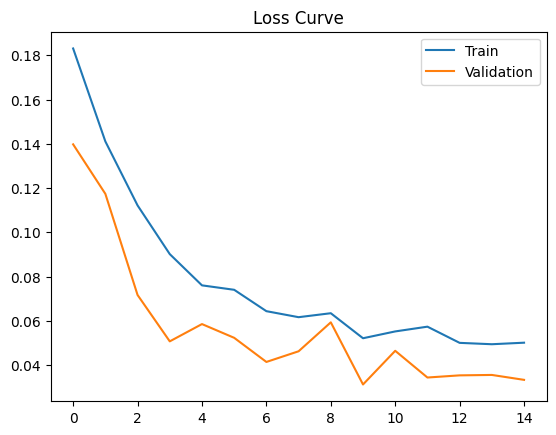

              precision    recall  f1-score   support

           0       0.78      0.85      0.81       108
           1       0.80      0.72      0.76        92

    accuracy                           0.79       200
   macro avg       0.79      0.78      0.79       200
weighted avg       0.79      0.79      0.79       200



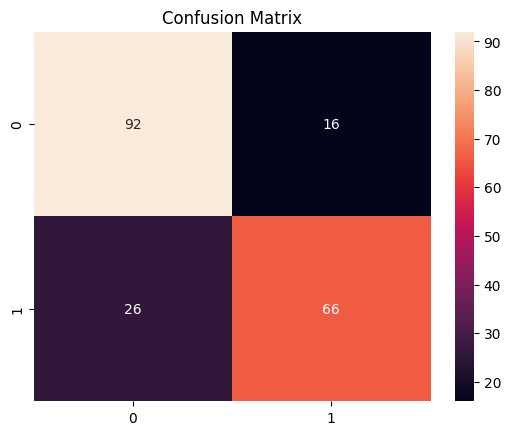

In [17]:
model = HybridModel()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = FocalLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

model, train_losses, val_losses, val_accuracies = train_model(model, train_loader, val_loader, criterion, optimizer)

plot_losses(train_losses, val_losses)
evaluate_model(model, test_loader)

Imagen original ──► CBAM ──► ResNet50 ──► Features espaciales
        │
        ▼
FFT (Fourier) ──► CNN ──► Features de frecuencia

           ▼
      Concatenación

           ▼
   Clasificador final

PRUEBAS MANUALES

In [46]:
from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import os

def subir_y_probar_rostro(model, class_names=['Real', 'IA']):
    """
    Abre una ventana para subir una imagen desde la PC local,
    la procesa y muestra la predicción del modelo.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    print("="*50)
    print("SUBE UNA IMAGEN DE UN ROSTRO DESDE TU PC")
    print("="*50)

    uploaded = files.upload()
    if not uploaded:
        print("No se subió ningún archivo.")
        return
    nombre_archivo = list(uploaded.keys())[0]
    print(f"\nArchivo '{nombre_archivo}' subido con éxito. Analizando...")

    try:
        imagen = Image.open(nombre_archivo).convert('RGB')

        imagen_tensor = transform(imagen).to(device)
        imagen_batch = imagen_tensor.unsqueeze(0)

        with torch.no_grad():
            outputs = model(imagen_batch)
            _, predicted = torch.max(outputs, 1)

        prediccion_final = class_names[predicted.item()]

        plt.figure(figsize=(5, 5))
        plt.imshow(imagen)

        plt.title(f"Veredicto:\nEs un rostro {prediccion_final.upper()}",
                  fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error al procesar la imagen subida. Asegúrate de que sea un formato válido (jpg, png)")

In [21]:
import random

def probar_imagen_aleatoria(model, dataset, class_names=['Real', 'IA']):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    indice_al_azar = random.randint(0, len(dataset) - 1)

    imagen_tensor, etiqueta_real_idx = dataset[indice_al_azar]

    imagen_batch = imagen_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(imagen_batch)
        _, predicted = torch.max(outputs, 1)

    prediccion = class_names[predicted.item()]
    realidad = class_names[etiqueta_real_idx]

    imagen_para_mostrar = imagen_tensor.permute(1, 2, 0).numpy()

    color_titulo = 'green' if prediccion == realidad else 'red'

    plt.figure(figsize=(4, 4))
    plt.imshow(imagen_para_mostrar)
    plt.title(f"Predicción: {prediccion} | Real: {realidad}", color=color_titulo, fontweight='bold')
    plt.axis('off')
    plt.show()


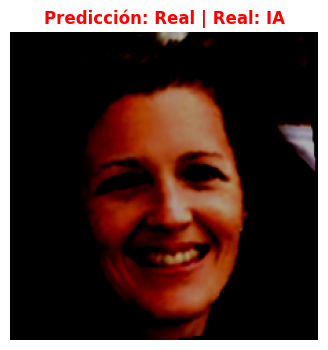

In [41]:
probar_imagen_aleatoria(model, test_dataset)

SUBE UNA IMAGEN DE UN ROSTRO DESDE TU PC


Saving photo-1542909168-82c3e7fdca5c.avif to photo-1542909168-82c3e7fdca5c (2).avif

Archivo 'photo-1542909168-82c3e7fdca5c (2).avif' subido con éxito. Analizando...


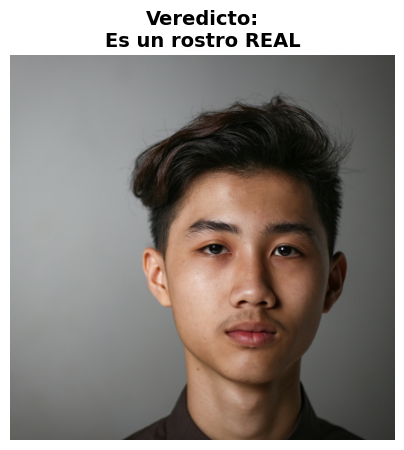

In [48]:
subir_y_probar_rostro(model)